## Цели практической работы

Проверить:
*   постановку нулевых и альтернативных гипотез,
*   выбор статистического критерия для проверки гипотез,
*   умение пользоваться Т-критериями,
*   умение пользоваться непараметрическими критериями.

Потренироваться в постановке односторонних и двусторонних тестов.

*Задача 1*

Студентов с одним и тем же начальным уровнем английского языка поделили на две группы. Одну группу учили по методике X, а другую по методике Y. После прохождения обучения им дали одинаковые финальные тесты на знание языка. За тест можно получить от 0 до 100 баллов. Проверьте, являются ли статистически значимыми различия в оценках между группой, которая училась по методике X, и группой, которая училась по методике Y.
______________
Опишите словами нулевую и альтернативную гипотезы. Проверьте гипотезы с помощью статистического критерия. Интерпретируйте получившиеся результаты. Уровень значимости = 5%.

Нулевая гипотеза: Различий нет  в оценках между группой, которая училась по методике X, и группой, которая училась по методике Y.

Альтернативная гипотеза: различия между результатами от  методик X и Y  есть.

In [ ]:
# строка для тех, кто работает в colab
!pip install scipy==1.7.1

In [5]:
import pandas as pd
from scipy import stats
from matplotlib import pyplot

ModuleNotFoundError: No module named 'scipy'

In [ ]:
df = pd.read_csv('hw1.csv')
df.head()

,X,Y
0,57,64
1,67,67
2,58,62
3,55,59
4,54,65


(array([ 4., 11., 15., 21., 12., 14., 15.,  5.,  2.,  1.]),
 array([50. , 52.3, 54.6, 56.9, 59.2, 61.5, 63.8, 66.1, 68.4, 70.7, 73. ]),
 <a list of 10 Patch objects>)

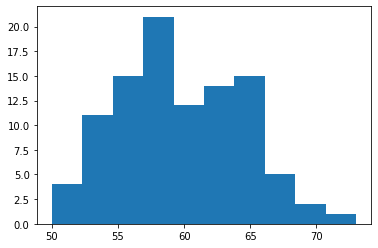

In [ ]:
# Ваш код здесь
#1  мы видим что выборки независимые
#2 проверяем является ли распределение нормальным
pyplot.hist(df.X)


(array([ 2.,  0., 10.,  9., 24., 12., 24.,  7.,  9.,  3.]),
 array([52. , 53.5, 55. , 56.5, 58. , 59.5, 61. , 62.5, 64. , 65.5, 67. ]),
 <a list of 10 Patch objects>)

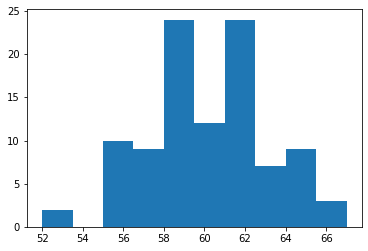

In [ ]:
pyplot.hist(df.Y)

Графики вышли не самые информативные трудно определить «колокольчик» особенно у второго.

Поэтому проверяем на тесте Шапиро-Уилка

In [ ]:
# делаем тест Шапиро-Уилка
stats.shapiro(df.X)

ShapiroResult(statistic=0.9843736886978149, pvalue=0.28597292304039)

In [ ]:
stats.shapiro(df.Y)

ShapiroResult(statistic=0.986425518989563, pvalue=0.4001672565937042)

В нашем случае p-value выше 5%  значит данные распределены нормально.

так же определим равна ли дисперсия 2х выборок проделаем тест Левиана

In [ ]:
stats.levene(df.X, df.Y)

LeveneResult(statistic=21.696306698497402, pvalue=5.850812069599258e-06)

p -value  меньше 5 % - а значит принимаем гипотезу о неравенстве дисперсий.

**Наши предварительные показатели следующие:**
- выборки не зависимые
- данные распределены нормально
- дисперсии не равны

 а значит применяем Т-Критерий Уэлча

In [ ]:
# Т-Критерий Уэлча применяем one - tail test предполагая, что  Y дает больше результата чем X
stats.ttest_ind(df.X, df.Y, equal_var=False, alternative='greater')

Ttest_indResult(statistic=-0.6292883911384963, pvalue=0.7349906051781099)

p- value оказался больше 5%, а значит нулевая гипотеза остается. И мы делаем вывод что Y  метод не влияет на  улучшения результатов

*Задача 2*

Ученые придумали добавку для уменьшения веса за две недели. Для проведения эксперимента и проверки добавки набрали тестовую группу из 60 человек. Было произведено два замера веса: один до приема добавок, другой после двухнедельного курса. Изучите данные и сделайте вывод, значимо или незначимо уменьшился вес у тестовой группы.

______________
Опишите словами нулевую и альтернативную гипотезы. Проверьте гипотезы с помощью статистического критерия. Интерпретируйте получившиеся результаты. Уровень значимости = 5%.

Нулевая гипотеза: добавка не оказывает  уменьшения веса за 2 недели

Альтернативная гипотеза:добавка оказывает результаты

In [ ]:
df2 = pd.read_csv('hw2.csv')
df2.head()

,before,after
0,66,68
1,68,68
2,59,60
3,64,62
4,75,71


(array([ 3.,  5., 10., 11.,  3., 12.,  7.,  4.,  4.,  1.]),
 array([58. , 60.8, 63.6, 66.4, 69.2, 72. , 74.8, 77.6, 80.4, 83.2, 86. ]),
 <a list of 10 Patch objects>)

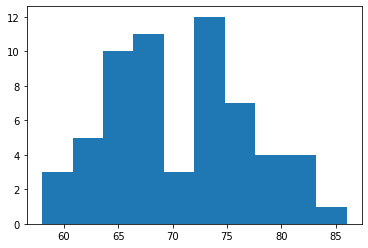

In [ ]:
# Ваш код здесь
# выборки являются зависимы
# определяем распределение нормальное или нет
pyplot.hist(df2.before)


(array([ 1.,  3.,  5.,  8.,  7., 13.,  9.,  5.,  7.,  2.]),
 array([56. , 58.6, 61.2, 63.8, 66.4, 69. , 71.6, 74.2, 76.8, 79.4, 82. ]),
 <a list of 10 Patch objects>)

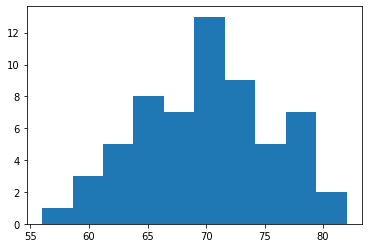

In [ ]:
pyplot.hist(df2.after)

In [ ]:
# графики показывают что нормальное , но убедимся на тесте
# делаем тест Шапиро-Уилка
stats.shapiro(df2.before)

ShapiroResult(statistic=0.9824520349502563, pvalue=0.5405492782592773)

In [ ]:
stats.shapiro(df2.after)

ShapiroResult(statistic=0.9882316589355469, pvalue=0.8322210311889648)

 В обоих случаях превышает  p- value  5%, а значит можем принять нулевую гипотезу о нормальности данных

**Наши предварительные показатели следующие:**
 - данные зависимы
 - распределены нормально
  
  значит применяем  **Парный Т- критерий**

In [ ]:
# предполагаем что показатели "после" будут меньше чем "до"
stats.ttest_rel(df2.after, df2.before, alternative='less')

Ttest_relResult(statistic=-2.055925757507072, pvalue=0.02211135004801021)

p- value оказался меньше 5% , а значит нулевая гипотеза отвергается и мы соглашаемся с альтернативной гипотезой, но незначимо уменьшился вес у тестовой группы.

*Задача 3*

Вы работаете аналитиком в приложении, которое собирает новости по интересам пользователя. Например, если пользователь увлечен книгами,  то приложение будет собирать ему самые свежие новости по новым книгам. Вы заметили, что пользователи редко посещают ваше приложение, а вам хотелось бы поднять их активность и видеть, что они заходят в приложение каждый день или еще чаще. То есть поднять их заинтересованность.

Вы и группа разработки решили присылать уведомления раз в день с самой популярной новостью по тематикам пользователя. Теперь вам нужно проверить, что эта гипотеза сработала, и заинтересованность пользователя выросла.
______________________
В датасете для каждого пользователя указано, сколько раз в неделю он заходил до появления уведомлений (колонка `before`) и сколько раз в неделю он стал заходить в приложение после появления уведомлений (колонка `after`)
______________
Опишите словами нулевую и альтернативную гипотезы. Проверьте гипотезы с помощью статистического критерия. Интерпретируйте получившиеся результаты. Уровень значимости = 5%.

Нулевая гипотеза: уведомление не меняет посещаемость пользователем приложения

Альтернативная гипотеза: уведомление изменяет посещаемость пользователя приложения

In [ ]:
df3 = pd.read_csv('hw3.csv')
df3.head()

,id,before,after
0,15,3,11
1,7,6,13
2,6,3,8
3,13,1,14
4,11,3,4


(array([ 5.,  7.,  0., 10.,  0.,  9.,  3.,  0.,  7.,  9.]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <a list of 10 Patch objects>)

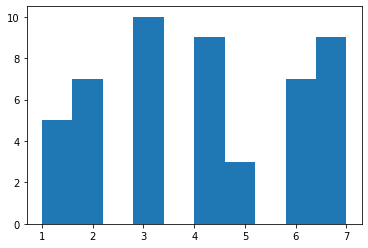

In [ ]:
# Ваш код здесь
# выборки являются зависимы
# определяем распределение нормальное или нет
pyplot.hist(df3.before)


(array([ 8.,  3.,  5.,  7.,  2.,  2., 10.,  2.,  3.,  8.]),
 array([ 1. ,  2.3,  3.6,  4.9,  6.2,  7.5,  8.8, 10.1, 11.4, 12.7, 14. ]),
 <a list of 10 Patch objects>)

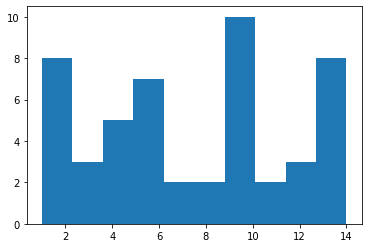

In [ ]:
pyplot.hist(df3.after)

In [ ]:
# графики показывают что ненормальное , но убедимся на тесте
# делаем тест Шапиро-Уилка
stats.shapiro(df3.before)

ShapiroResult(statistic=0.9824520349502563, pvalue=0.5405492782592773)

In [ ]:
stats.shapiro(df3.after)

ShapiroResult(statistic=0.9323503375053406, pvalue=0.006789296865463257)

если до соотвествует нормальному распределению, то данные после  не соотвествуют нормальному распределению они меньше 5%

**Наши предварительные показатели следующие:**

- данные зависимы

- распределены ненормально

значит применяем  Знаковый критерий Вилконсона

In [ ]:
# one - tail test-"после" больше чем "до"

stats.wilcoxon(df3.after, df3.before, alternative='greater')

WilcoxonResult(statistic=919.5, pvalue=1.6672412784258823e-05)

значение p-value мало, а это значит что нулевая гипотеза отвергается и принимается альтернативная

*Задача 4*

Компания X тестирует продажу своего продукта через два разных сайта. На оба сайта приходит одинаковое количество пользователей. Причем выборки пользователей не пересекаются, то есть если пользователь увидел сайт 1, он уже не посетит сайт 2. Проверьте гипотезу, что средний чек по пользователям на сайте 1 отличается от среднего чека пользователей на сайте 2 (период сравнения — один месяц).

Опишите словами нулевую и альтернативную гипотезы. Проверьте гипотезы с помощью статистического критерия. Интерпретируйте получившиеся результаты. Уровень значимости = 5%.

Нулевая гипотеза: Средний чек не меняется на 2м сайте

Альтернативная гипотеза: средний чек  меняется на 2м сайте

In [ ]:
df4 = pd.read_csv('hw4.csv')
df4.head()

,site1,site2
0,193,720
1,8426,2099
2,4024,2282
3,1447,2455
4,2274,7988


(array([30., 11.,  9., 12.,  9.,  5.,  4.,  6.,  8.,  6.]),
 array([   0. ,  978.2, 1956.4, 2934.6, 3912.8, 4891. , 5869.2, 6847.4,
        7825.6, 8803.8, 9782. ]),
 <a list of 10 Patch objects>)

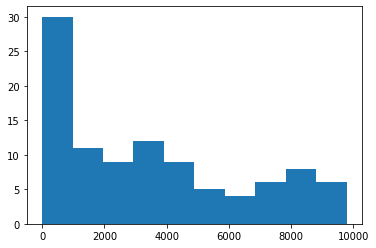

In [ ]:
# Ваш код здесь
# выборки не зависимы
# определяем распределение нормальное или нет
pyplot.hist(df4.site1)

(array([15.,  9., 13.,  8., 12.,  8.,  6.,  8.,  9., 12.]),
 array([   0. ,  979.3, 1958.6, 2937.9, 3917.2, 4896.5, 5875.8, 6855.1,
        7834.4, 8813.7, 9793. ]),
 <a list of 10 Patch objects>)

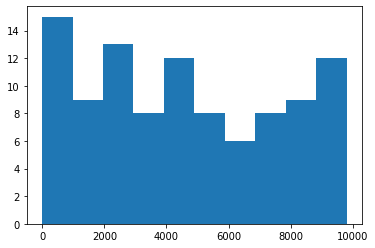

In [ ]:
pyplot.hist(df4.site2)

  по гистограмме не нормальное, проверяем по тесту  Шапиро-Уилка

In [ ]:
stats.shapiro(df4.site1)

ShapiroResult(statistic=0.8995055556297302, pvalue=1.3402153626884683e-06)

In [ ]:
stats.shapiro(df4.site2)

ShapiroResult(statistic=0.937269926071167, pvalue=0.00013190472964197397)

 p -value ниже  5% порога,данные распределены ненормально.

**Наши предварительные показатели следующие:**

- данные независимы

- выборки из не нормального распределения

значит применяем критерий Манна-Уитни

In [ ]:
# one - tail test site1 > site2 посетителей
stats.mannwhitneyu(df4.site1, df4.site2, alternative='greater')

MannwhitneyuResult(statistic=3889.5, pvalue=0.9966921511057955)

значение p value   очень большое мы не можем отвергнуть нулевую гипотезу

In [ ]:
# one - tail test site1 < site2 посетителей
stats.mannwhitneyu(df4.site1, df4.site2, alternative='less')

MannwhitneyuResult(statistic=3889.5, pvalue=0.0033323485988455952)

значение p value    меньше 5 % это значит мы можем отвергнуть нулевую гипотезу

**Подтверждение, что сайт 2  повысит средний чек покупателя не подтверждается**